<a href="https://colab.research.google.com/github/phuonglinhday1048-hue/Phantichdl-hs/blob/main/Lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# CÂU 1: KHỞI TẠO DỮ LIỆU
np.random.seed(42)
n = 500
MaKH = [f"KH{i:03d}" for i in range(1, n + 1)]
Tuoi = np.random.randint(18, 71, n).astype(float)
nan_index = np.random.choice(n, 10, replace=False)
Tuoi[nan_index] = np.nan
ThuNhap = np.random.uniform(5, 50, n)
outlier_index = np.random.choice(n, 5, replace=False)
ThuNhap[outlier_index] = np.random.uniform(150, 200, 5)
GioiTinh = np.random.choice(['Nam', 'Nữ'], n)
gender_nan = np.random.choice(n, 15, replace=False)
GioiTinh = GioiTinh.astype(object)
GioiTinh[gender_nan] = np.nan
ThanhPho = np.random.choice(
    ['Hà Nội', 'Đà Nẵng', 'TP.HCM'],
    n
)
# Tổng chi tiêu (có tương quan nhẹ với thu nhập)
TongChiTieu = ThuNhap * np.random.uniform(0.4, 0.8, n) + np.random.normal(0, 2, n)
# Tạo DataFrame
df_khachhang = pd.DataFrame({
    "MaKH": MaKH,
    "Tuoi": Tuoi,
    "ThuNhap": ThuNhap,
    "GioiTinh": GioiTinh,
    "ThanhPho": ThanhPho,
    "TongChiTieu": TongChiTieu
})

print("5 dòng đầu:")
print(df_khachhang.head())

5 dòng đầu:
    MaKH  Tuoi    ThuNhap GioiTinh ThanhPho  TongChiTieu
0  KH001  56.0  19.865682      NaN   Hà Nội    10.678197
1  KH002  69.0  47.016132      Nam   TP.HCM    24.992669
2  KH003  46.0   5.339046      Nam   Hà Nội     6.680794
3  KH004  32.0  15.139976       Nữ   TP.HCM    13.454468
4  KH005  60.0  21.441057      Nam   Hà Nội    10.284279


In [ ]:
# CÂU 2: XỬ LÝ GIÁ TRỊ KHUYẾT
print("\nSố lượng giá trị khuyết:")
print(df_khachhang.isnull().sum())

# Điền tuổi bằng Median
df_khachhang["Tuoi"].fillna(df_khachhang["Tuoi"].median(), inplace=True)

# Điền giới tính bằng Mode
df_khachhang["GioiTinh"].fillna(df_khachhang["GioiTinh"].mode()[0], inplace=True)

print("\nSau khi xử lý:")
print(df_khachhang.isnull().sum())


Số lượng giá trị khuyết:
MaKH            0
Tuoi           10
ThuNhap         0
GioiTinh       15
ThanhPho        0
TongChiTieu     0
dtype: int64

Sau khi xử lý:
MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64


/tmp/ipykernel_490/555828914.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_khachhang["Tuoi"].fillna(df_khachhang["Tuoi"].median(), inplace=True)
/tmp/ipykernel_490/555828914.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [ ]:
# CÂU 3: ONE-HOT ENCODING
one_hot = pd.get_dummies(df_khachhang["ThanhPho"], prefix="ThanhPho")

df_khachhang = pd.concat([df_khachhang, one_hot], axis=1)

print("\nDataFrame sau One-Hot:")
print(df_khachhang.head())


DataFrame sau One-Hot:
    MaKH  Tuoi    ThuNhap GioiTinh ThanhPho  TongChiTieu  ThanhPho_Hà Nội  \
0  KH001  56.0  19.865682       Nữ   Hà Nội    10.678197             True   
1  KH002  69.0  47.016132      Nam   TP.HCM    24.992669            False   
2  KH003  46.0   5.339046      Nam   Hà Nội     6.680794             True   
3  KH004  32.0  15.139976       Nữ   TP.HCM    13.454468            False   
4  KH005  60.0  21.441057      Nam   Hà Nội    10.284279             True   

   ThanhPho_TP.HCM  ThanhPho_Đà Nẵng  
0            False             False  
1             True             False  
2            False             False  
3             True             False  
4            False             False  


In [ ]:
# CÂU 4: PHÁT HIỆN OUTLIER (IQR)

Q1 = df_khachhang["ThuNhap"].quantile(0.25)
Q3 = df_khachhang["ThuNhap"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("\nQ1 =", Q1)
print("Q3 =", Q3)
print("Lower Bound =", lower)
print("Upper Bound =", upper)

# Lọc bỏ Outlier
df_no_outlier = df_khachhang[
    (df_khachhang["ThuNhap"] >= lower) &
    (df_khachhang["ThuNhap"] <= upper)
]

print("\nSố dòng trước:", len(df_khachhang))
print("Số dòng sau khi xóa Outlier:", len(df_no_outlier))


Q1 = 17.487805590331565
Q3 = 39.69730000766945
Lower Bound = -15.826436035675261
Upper Bound = 73.01154163367627

Số dòng trước: 500
Số dòng sau khi xóa Outlier: 495


In [ ]:
# CÂU 5: CHUẨN HÓA DỮ LIỆU
scaler = MinMaxScaler()

df_no_outlier["TongChiTieu_Scaled"] = scaler.fit_transform(
    df_no_outlier[["TongChiTieu"]]
)

print("\n5 dòng đầu sau khi chuẩn hóa:")
print(df_no_outlier[["TongChiTieu", "TongChiTieu_Scaled"]].head())


5 dòng đầu sau khi chuẩn hóa:
   TongChiTieu  TongChiTieu_Scaled
0    10.678197            0.304558
1    24.992669            0.669164
2     6.680794            0.202739
3    13.454468            0.375273
4    10.284279            0.294524


/tmp/ipykernel_490/1649432166.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outlier["TongChiTieu_Scaled"] = scaler.fit_transform(


In [ ]:
#CÂU 6: LỌC DỮ LIỆU
df_nu_hanoi = df_khachhang[
    (df_khachhang["GioiTinh"] == "Nữ") &
    (df_khachhang["Tuoi"] > 30) &
    (df_khachhang["ThanhPho"] == "Hà Nội")
]

print("\n5 dòng đầu của kết quả lọc:")
print(df_nu_hanoi.head())


5 dòng đầu của kết quả lọc:
     MaKH  Tuoi    ThuNhap GioiTinh ThanhPho  TongChiTieu  ThanhPho_Hà Nội  \
0   KH001  56.0  19.865682       Nữ   Hà Nội    10.678197             True   
16  KH017  41.0  30.919929       Nữ   Hà Nội    23.543257             True   
18  KH019  39.0   5.238500       Nữ   Hà Nội     4.280687             True   
19  KH020  70.0  48.878022       Nữ   Hà Nội    32.241098             True   
21  KH022  41.0  37.530324       Nữ   Hà Nội    21.383238             True   

    ThanhPho_TP.HCM  ThanhPho_Đà Nẵng  
0             False             False  
16            False             False  
18            False             False  
19            False             False  
21            False             False  


In [ ]:
#Câu 7: Gom nhóm và Thống kê (Aggregation)
thong_ke = df_khachhang.groupby("ThanhPho")["TongChiTieu"].agg(
    TrungBinh="mean",
    Tong="sum"
)

print(thong_ke)

          TrungBinh         Tong
ThanhPho                        
Hà Nội    17.184197  3144.708061
TP.HCM    18.824266  3124.828195
Đà Nẵng   17.992659  2716.891523


In [ ]:
#Câu 8: Kỹ nghệ đặc trưng (Feature Engineering)
bins = [18, 30, 45, 60, 100]

labels = [
    "18-30",
    "31-45",
    "46-60",
    "Trên 60"
]

df_khachhang["NhomTuoi"] = pd.cut(
    df_khachhang["Tuoi"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df_khachhang[["Tuoi", "NhomTuoi"]].head())

   Tuoi NhomTuoi
0  56.0    46-60
1  69.0  Trên 60
2  46.0    46-60
3  32.0    31-45
4  60.0    46-60


                 Tuoi   ThuNhap  TongChiTieu
Tuoi         1.000000 -0.027787    -0.022492
ThuNhap     -0.027787  1.000000     0.929944
TongChiTieu -0.022492  0.929944     1.000000


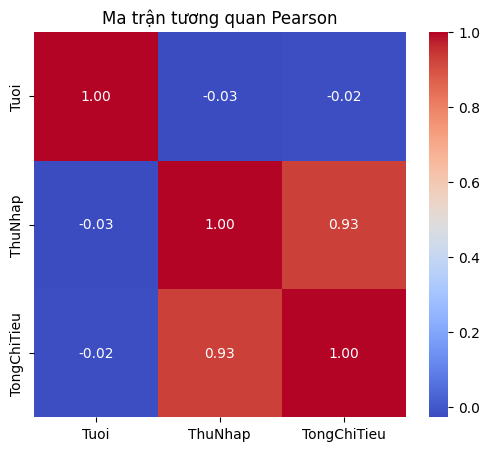

In [ ]:
#Câu 9: Ma trận tương quan (Correlation Matrix)
corr = df_khachhang[
    ["Tuoi", "ThuNhap", "TongChiTieu"]
].corr(method="pearson")

print(corr)
plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Ma trận tương quan Pearson")
plt.show()

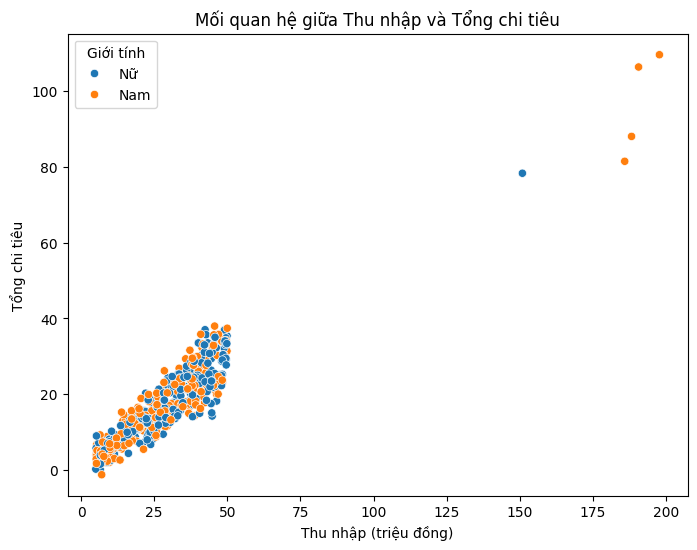

In [ ]:
#Câu 10: Trực quan hóa dữ liệu (Scatter Plot)
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_khachhang,
    x="ThuNhap",
    y="TongChiTieu",
    hue="GioiTinh"
)

plt.title("Mối quan hệ giữa Thu nhập và Tổng chi tiêu")
plt.xlabel("Thu nhập (triệu đồng)")
plt.ylabel("Tổng chi tiêu")
plt.legend(title="Giới tính")

plt.show()

In [17]:
pip show tensorflow


Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tf_keras, ydf_tf


In [18]:
#PHẦN 2: ỨNG DỤNG HỌC Sâu - MẠNG NƠ-RON TÍCH CHẬP
#Câu 11: Xây dựng và Huấn luyện mô hình CNN
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

# ============================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# ============================

# Tải bộ dữ liệu Fashion MNIST
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

# Chuẩn hóa giá trị pixel về [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape để thêm kênh màu (grayscale)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Kích thước tập train:", x_train.shape)
print("Kích thước tập test:", x_test.shape)

# ============================
# 2. XÂY DỰNG KIẾN TRÚC CNN
# ============================

model = models.Sequential([
    # Lớp Conv2D
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    # Lớp MaxPooling
    layers.MaxPooling2D(pool_size=(2,2)),

    # Duỗi dữ liệu
    layers.Flatten(),

    # Lớp Dense 64 nút
    layers.Dense(64, activation='relu'),

    # Lớp đầu ra
    layers.Dense(10, activation='softmax')
])

# Hiển thị cấu trúc mô hình
model.summary()

# ============================
# 3. BIÊN DỊCH VÀ HUẤN LUYỆN
# ============================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# ============================
# 4. ĐÁNH GIÁ MÔ HÌNH
# ============================

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nĐộ chính xác trên tập kiểm thử:", test_accuracy)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập train: (60000, 28, 28, 1)
Kích thước tập test: (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8494 - loss: 0.4284 - val_accuracy: 0.8855 - val_loss: 0.3240
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8978 - loss: 0.2876 - val_accuracy: 0.8967 - val_loss: 0.2916
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9107 - loss: 0.2450 - val_accuracy: 0.9107 - val_loss: 0.2542
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9212 - loss: 0.2161 - val_accuracy: 0.9087 - val_loss: 0.2573
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9302 - loss: 0.1910 - val_accuracy: 0.9116 - val_loss: 0.2511
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9090 - loss: 0.2579

Độ chính xác trên tập kiểm thử: 0.9089999794960022
